# Stack Overflow Developer Survey 2025
## Notebook 3 — AI Adoption Classifier Pipelines

**Research question:** Can we predict which developers adopt AI tools — and does experience drive adoption or suppress it?

**Target:** `UsesAI` (binary — 1 = uses AI tools, 0 = does not)

**Class imbalance:** 81.6% positive class. This is the central modelling challenge. A naive model that predicts 'Uses AI' for every respondent achieves 81.6% accuracy but has zero predictive value. All three pipelines use `class_weight='balanced'` to force the model to learn what actually distinguishes non-adopters.

**Three independent pipelines:**

| Pipeline | Model | Scaling | class_weight |
|---|---|---|---|
| 1 | Logistic Regression (baseline) | Yes | balanced |
| 2 | Random Forest Classifier | No | balanced |
| 3 | XGBoost Classifier | No | scale_pos_weight |

**Primary metric:** ROC-AUC (handles imbalance gracefully, threshold-agnostic)
**Secondary metric:** F1 (harmonic mean of precision/recall — penalises missing the minority class)

**Why NOT accuracy?** At 81.6% class imbalance, accuracy is meaningless as a selection metric. A model that says 'Uses AI' for everyone scores 81.6% accuracy and 0% on anything that matters.

**Workflow per pipeline:**
```
X_clf_train / y_clf_train  (loaded from Notebook 1 artefacts)
│
└── 5-Fold StratifiedKFold CV  →  ROC-AUC / F1  →  comparison table
         │
         └── Winner selected → retrained on full X_clf_train
                  │
                  └── Final evaluation on X_clf_test (ONCE)
                           │
                           ├── Classification report + confusion matrix
                           └── Feature importance → WorkExp rank → confound answer
```

In [1]:
class Config:
    DATA_DIR        = './data/'
    RESULTS_DIR     = './results/classification/'
    MODELS_DIR      = './models/classification/'
    RANDOM_STATE    = 42
    N_FOLDS         = 5
    CONTINUOUS_COLS = ['WorkExp']
    # Expected class balance from EDA — used for scale_pos_weight in XGBoost
    # scale_pos_weight = count(negative class) / count(positive class)
    # At 81.6% positive: scale_pos_weight ≈ 0.184 / 0.816 ≈ 0.225
    EXPECTED_POS_RATE = 0.816

config = Config()
print('Config loaded.')

Config loaded.


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.preprocessing       import StandardScaler
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier
from sklearn.model_selection     import StratifiedKFold, cross_validate
from sklearn.metrics             import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from xgboost                     import XGBClassifier
import joblib
import shap

SEED = config.RANDOM_STATE
np.random.seed(SEED)

os.makedirs(config.RESULTS_DIR, exist_ok=True)
os.makedirs(config.MODELS_DIR,  exist_ok=True)

print('Imports complete.')

Imports complete.


## LOAD SPLIT ARTEFACTS

Loads the identical train/test split produced by Notebook 1. Rows are the same as the regression notebook — only the feature matrix and target differ.

In [3]:
X_train = pd.read_parquet(os.path.join(config.DATA_DIR, 'X_clf_train.parquet'))
X_test  = pd.read_parquet(os.path.join(config.DATA_DIR, 'X_clf_test.parquet'))
y_train = pd.read_parquet(os.path.join(config.DATA_DIR, 'y_clf_train.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(config.DATA_DIR, 'y_clf_test.parquet')).squeeze()

print('Loaded from Notebook 1 artefacts:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}  [LOCKED until final evaluation]')

# Class balance check
train_pos_rate = y_train.mean()
test_pos_rate  = y_test.mean()
print(f'\n  Train class balance : {train_pos_rate:.4f} positive ({y_train.sum():,} AI users / {len(y_train):,})')
print(f'  Test  class balance : {test_pos_rate:.4f} positive ({y_test.sum():,} AI users / {len(y_test):,})')

# Compute scale_pos_weight for XGBoost from actual training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'\n  XGBoost scale_pos_weight = {neg_count} / {pos_count} = {scale_pos_weight:.4f}')

# Leakage assertions
assert 'UsesAI' not in X_train.columns, 'Target leakage: UsesAI in classification features'
assert 'log_salary' not in X_train.columns, 'UsesAI cannot learn from salary (outcome variable)'
print('\nAssertions passed — no target leakage.')

Loaded from Notebook 1 artefacts:
  X_train : (14411, 102)
  X_test  : (3603, 102)  [LOCKED until final evaluation]

  Train class balance : 0.8163 positive (11,764 AI users / 14,411)
  Test  class balance : 0.8163 positive (2,941 AI users / 3,603)

  XGBoost scale_pos_weight = 2647 / 11764 = 0.2250

Assertions passed — no target leakage.


## CLASS IMBALANCE — RATIONALE

81.6% of respondents report using AI tools (UsesAI = 1). This severe class imbalance means accuracy is an uninformative metric — a model that always predicts 'Uses AI' achieves 81.6% accuracy without any learning. Three adjustments are applied throughout: (1) StratifiedKFold to preserve the class ratio in each fold, (2) class_weight='balanced' / scale_pos_weight to up-weight minority-class errors during training, and (3) ROC-AUC as the primary CV selection metric.

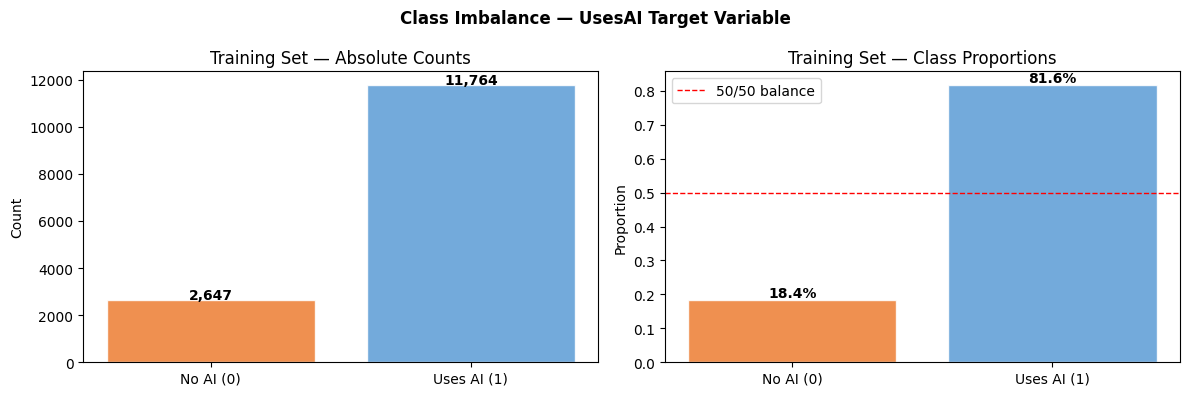

Class imbalance handling strategy:
  Logistic Regression : class_weight="balanced" (sklearn auto-weights each class inversely)
  Random Forest       : class_weight="balanced" (same mechanism, per-tree)
  XGBoost             : scale_pos_weight=0.225 (equivalent mechanism for gradient boosting)
  Primary metric      : ROC-AUC (threshold-agnostic, handles imbalance correctly)
  Secondary metric    : F1 (penalises missing the minority non-adopter class)
  Avoided metric      : Accuracy (meaningless at 81.6% imbalance)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Imbalance — UsesAI Target Variable', fontsize=12, fontweight='bold')

# Absolute counts
counts = y_train.value_counts().sort_index()
axes[0].bar(['No AI (0)', 'Uses AI (1)'], counts.values,
            color=['#ED7D31', '#5B9BD5'], alpha=0.85, edgecolor='white')
axes[0].set_title('Training Set — Absolute Counts')
axes[0].set_ylabel('Count')
for i, (bar, v) in enumerate(zip(axes[0].patches, counts.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}',
                 ha='center', fontweight='bold')

# Proportions
axes[1].bar(['No AI (0)', 'Uses AI (1)'],
            [1 - train_pos_rate, train_pos_rate],
            color=['#ED7D31', '#5B9BD5'], alpha=0.85, edgecolor='white')
axes[1].set_title('Training Set — Class Proportions')
axes[1].set_ylabel('Proportion')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='50/50 balance')
axes[1].legend()
axes[1].text(0, 1 - train_pos_rate + 0.01, f'{(1-train_pos_rate)*100:.1f}%', ha='center', fontweight='bold')
axes[1].text(1, train_pos_rate + 0.01, f'{train_pos_rate*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Class imbalance handling strategy:')
print(f'  Logistic Regression : class_weight="balanced" (sklearn auto-weights each class inversely)')
print(f'  Random Forest       : class_weight="balanced" (same mechanism, per-tree)')
print(f'  XGBoost             : scale_pos_weight={scale_pos_weight:.3f} (equivalent mechanism for gradient boosting)')
print(f'  Primary metric      : ROC-AUC (threshold-agnostic, handles imbalance correctly)')
print(f'  Secondary metric    : F1 (penalises missing the minority non-adopter class)')
print(f'  Avoided metric      : Accuracy (meaningless at {train_pos_rate*100:.1f}% imbalance)')

## PIPELINE DEFINITIONS

In [5]:
# ── Preprocessing ──────────────────────────────────────────────────────────
binary_cols = [c for c in X_train.columns if c not in config.CONTINUOUS_COLS]

preprocessor_with_scaling = ColumnTransformer([
    ('scale',       StandardScaler(), config.CONTINUOUS_COLS),
    ('passthrough', 'passthrough',    binary_cols)
])

preprocessor_passthrough = ColumnTransformer([
    ('passthrough', 'passthrough', X_train.columns.tolist())
])

# ── Pipeline 1: Logistic Regression ───────────────────────────────────────
# class_weight='balanced': sklearn computes w_j = n_samples / (n_classes * n_j)
# This upweights non-AI-users (minority) and downweights AI-users (majority)
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_with_scaling),
    ('model', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

# ── Pipeline 2: Random Forest Classifier ──────────────────────────────────
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_passthrough),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

# ── Pipeline 3: XGBoost Classifier ────────────────────────────────────────
# XGBoost uses scale_pos_weight instead of class_weight
# scale_pos_weight = neg_count / pos_count — equivalent to balanced weighting
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_passthrough),
    ('model', XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    ))
])

PIPELINES = {
    'Logistic Regression' : pipeline_lr,
    'Random Forest'       : pipeline_rf,
    'XGBoost'             : pipeline_xgb,
}

print('Pipelines defined:')
for name in PIPELINES:
    print(f'  {name}')

Pipelines defined:
  Logistic Regression
  Random Forest
  XGBoost


## Logistic Regression

Logistic Regression is the interpretable baseline. Its WorkExp coefficient provides a direct, linear estimate of experience's effect on adoption odds — a clean answer to the research question regardless of whether LR wins the CV comparison. class_weight='balanced' is applied to handle the 81.6% positive class.

In [6]:
print('Running Pipeline 1: Logistic Regression — 5-Fold StratifiedKFold')
print('-' * 60)

# StratifiedKFold ensures each fold preserves the 81.6%/18.4% class ratio
# Critical for imbalanced datasets — plain KFold could produce a fold with very few non-AI-users
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=SEED)

cv_lr = cross_validate(
    pipeline_lr, X_train, y_train,
    cv=skf,
    scoring={
        'roc_auc' : 'roc_auc',
        'f1'      : 'f1',
        'accuracy': 'accuracy'
    },
    return_train_score=True,
    n_jobs=-1
)

lr_results = {
    'cv_auc'      : cv_lr['test_roc_auc'].mean(),
    'cv_auc_std'  : cv_lr['test_roc_auc'].std(),
    'cv_f1'       : cv_lr['test_f1'].mean(),
    'cv_f1_std'   : cv_lr['test_f1'].std(),
    'cv_acc'      : cv_lr['test_accuracy'].mean(),
    'train_auc'   : cv_lr['train_roc_auc'].mean(),
    'train_f1'    : cv_lr['train_f1'].mean(),
    'fold_aucs'   : cv_lr['test_roc_auc'].tolist(),
    'fold_f1s'    : cv_lr['test_f1'].tolist()
}

print(f"  CV ROC-AUC  : {lr_results['cv_auc']:.4f}  ±{lr_results['cv_auc_std']:.4f}")
print(f"  CV F1       : {lr_results['cv_f1']:.4f}  ±{lr_results['cv_f1_std']:.4f}")
print(f"  CV Accuracy : {lr_results['cv_acc']:.4f}  (shown for context only — not selection metric)")
print(f"  Train AUC   : {lr_results['train_auc']:.4f}  (gap={lr_results['cv_auc']-lr_results['train_auc']:.4f})")
print(f"  Fold AUCs   : {[f'{v:.4f}' for v in lr_results['fold_aucs']]}")

Running Pipeline 1: Logistic Regression — 5-Fold StratifiedKFold
------------------------------------------------------------
  CV ROC-AUC  : 0.6837  ±0.0093
  CV F1       : 0.7227  ±0.0056
  CV Accuracy : 0.6178  (shown for context only — not selection metric)
  Train AUC   : 0.7035  (gap=-0.0198)
  Fold AUCs   : ['0.6934', '0.6716', '0.6797', '0.6957', '0.6781']


## Random Forest Classifier

In [7]:
print('Running Pipeline 2: Random Forest Classifier — 5-Fold StratifiedKFold')
print('-' * 60)

cv_rf = cross_validate(
    pipeline_rf, X_train, y_train,
    cv=skf,
    scoring={
        'roc_auc' : 'roc_auc',
        'f1'      : 'f1',
        'accuracy': 'accuracy'
    },
    return_train_score=True,
    n_jobs=-1
)

rf_results = {
    'cv_auc'      : cv_rf['test_roc_auc'].mean(),
    'cv_auc_std'  : cv_rf['test_roc_auc'].std(),
    'cv_f1'       : cv_rf['test_f1'].mean(),
    'cv_f1_std'   : cv_rf['test_f1'].std(),
    'cv_acc'      : cv_rf['test_accuracy'].mean(),
    'train_auc'   : cv_rf['train_roc_auc'].mean(),
    'train_f1'    : cv_rf['train_f1'].mean(),
    'fold_aucs'   : cv_rf['test_roc_auc'].tolist(),
    'fold_f1s'    : cv_rf['test_f1'].tolist()
}

print(f"  CV ROC-AUC  : {rf_results['cv_auc']:.4f}  ±{rf_results['cv_auc_std']:.4f}")
print(f"  CV F1       : {rf_results['cv_f1']:.4f}  ±{rf_results['cv_f1_std']:.4f}")
print(f"  CV Accuracy : {rf_results['cv_acc']:.4f}")
print(f"  Train AUC   : {rf_results['train_auc']:.4f}  (gap={rf_results['cv_auc']-rf_results['train_auc']:.4f})")
print(f"  Fold AUCs   : {[f'{v:.4f}' for v in rf_results['fold_aucs']]}")

Running Pipeline 2: Random Forest Classifier — 5-Fold StratifiedKFold
------------------------------------------------------------
  CV ROC-AUC  : 0.6782  ±0.0112
  CV F1       : 0.8229  ±0.0046
  CV Accuracy : 0.7226
  Train AUC   : 0.9066  (gap=-0.2284)
  Fold AUCs   : ['0.6916', '0.6614', '0.6844', '0.6846', '0.6690']


## XGBoost Classifier

In [8]:
print('Running Pipeline 3: XGBoost Classifier — 5-Fold StratifiedKFold')
print('-' * 60)

cv_xgb = cross_validate(
    pipeline_xgb, X_train, y_train,
    cv=skf,
    scoring={
        'roc_auc' : 'roc_auc',
        'f1'      : 'f1',
        'accuracy': 'accuracy'
    },
    return_train_score=True,
    n_jobs=-1
)

xgb_results = {
    'cv_auc'      : cv_xgb['test_roc_auc'].mean(),
    'cv_auc_std'  : cv_xgb['test_roc_auc'].std(),
    'cv_f1'       : cv_xgb['test_f1'].mean(),
    'cv_f1_std'   : cv_xgb['test_f1'].std(),
    'cv_acc'      : cv_xgb['test_accuracy'].mean(),
    'train_auc'   : cv_xgb['train_roc_auc'].mean(),
    'train_f1'    : cv_xgb['train_f1'].mean(),
    'fold_aucs'   : cv_xgb['test_roc_auc'].tolist(),
    'fold_f1s'    : cv_xgb['test_f1'].tolist()
}

print(f"  CV ROC-AUC  : {xgb_results['cv_auc']:.4f}  ±{xgb_results['cv_auc_std']:.4f}")
print(f"  CV F1       : {xgb_results['cv_f1']:.4f}  ±{xgb_results['cv_f1_std']:.4f}")
print(f"  CV Accuracy : {xgb_results['cv_acc']:.4f}")
print(f"  Train AUC   : {xgb_results['train_auc']:.4f}  (gap={xgb_results['cv_auc']-xgb_results['train_auc']:.4f})")
print(f"  Fold AUCs   : {[f'{v:.4f}' for v in xgb_results['fold_aucs']]}")

Running Pipeline 3: XGBoost Classifier — 5-Fold StratifiedKFold
------------------------------------------------------------
  CV ROC-AUC  : 0.6707  ±0.0156
  CV F1       : 0.7503  ±0.0071
  CV Accuracy : 0.6434
  Train AUC   : 0.8268  (gap=-0.1561)
  Fold AUCs   : ['0.6859', '0.6434', '0.6796', '0.6811', '0.6634']


## CV RESULTS COMPARISON TABLE

In [9]:
all_cv = {
    'Logistic Regression' : lr_results,
    'Random Forest'       : rf_results,
    'XGBoost'             : xgb_results,
}

comparison_df = pd.DataFrame([
    {
        'Model'              : name,
        'CV ROC-AUC (avg)'   : f"{res['cv_auc']:.4f}",
        'CV ROC-AUC (±std)'  : f"{res['cv_auc_std']:.4f}",
        'CV F1 (avg)'        : f"{res['cv_f1']:.4f}",
        'CV F1 (±std)'       : f"{res['cv_f1_std']:.4f}",
        'CV Accuracy'        : f"{res['cv_acc']:.4f}",
        'Train AUC'          : f"{res['train_auc']:.4f}",
        'Overfit gap (AUC)'  : f"{res['cv_auc'] - res['train_auc']:.4f}",
    }
    for name, res in all_cv.items()
])

print('\n5-FOLD STRATIFIEDKFOLD COMPARISON — AI ADOPTION CLASSIFIER')
print('=' * 90)
print(comparison_df.to_string(index=False))
print('=' * 90)
print('\nReading guide:')
print('  Higher ROC-AUC = better discrimination between AI users and non-users')
print('  Higher F1      = better balance of precision/recall on both classes')
print('  Accuracy is shown for context — DO NOT use it for model selection here')
print(f'  A model predicting everyone as AI user scores {train_pos_rate*100:.1f}% accuracy — useless')

comparison_df.to_csv(os.path.join(config.RESULTS_DIR, 'cv_comparison.csv'), index=False)
print('\nComparison table saved.')


5-FOLD STRATIFIEDKFOLD COMPARISON — AI ADOPTION CLASSIFIER
              Model CV ROC-AUC (avg) CV ROC-AUC (±std) CV F1 (avg) CV F1 (±std) CV Accuracy Train AUC Overfit gap (AUC)
Logistic Regression           0.6837            0.0093      0.7227       0.0056      0.6178    0.7035           -0.0198
      Random Forest           0.6782            0.0112      0.8229       0.0046      0.7226    0.9066           -0.2284
            XGBoost           0.6707            0.0156      0.7503       0.0071      0.6434    0.8268           -0.1561

Reading guide:
  Higher ROC-AUC = better discrimination between AI users and non-users
  Higher F1      = better balance of precision/recall on both classes
  Accuracy is shown for context — DO NOT use it for model selection here
  A model predicting everyone as AI user scores 81.6% accuracy — useless

Comparison table saved.


Note: Random Forest achieves the highest CV F1 (0.8229) but the lowest CV ROC-AUC (0.6782) and the most severe overfit gap (Train AUC 0.9066 vs CV AUC 0.6782). The high F1 is explained by the class imbalance: an untuned RF defaults to predicting the majority class, achieving high F1 for 'Uses AI = 1' without meaningful discriminative power. Model selection uses ROC-AUC — the correct metric for imbalanced classification.

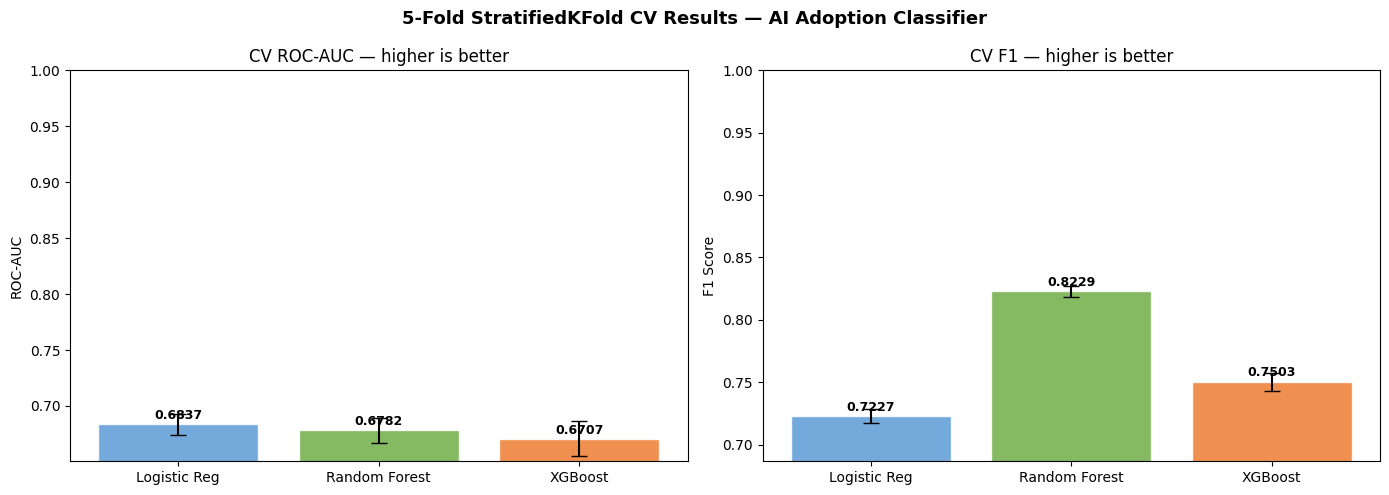

In [10]:
# ── CV comparison visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold StratifiedKFold CV Results — AI Adoption Classifier', fontsize=13, fontweight='bold')

model_names = list(all_cv.keys())
short_names = ['Logistic Reg', 'Random Forest', 'XGBoost']
cv_aucs     = [all_cv[n]['cv_auc']     for n in model_names]
cv_auc_stds = [all_cv[n]['cv_auc_std'] for n in model_names]
cv_f1s      = [all_cv[n]['cv_f1']      for n in model_names]
cv_f1_stds  = [all_cv[n]['cv_f1_std']  for n in model_names]
colors      = ['#5B9BD5', '#70AD47', '#ED7D31']

# ROC-AUC bars
bars = axes[0].bar(short_names, cv_aucs, yerr=cv_auc_stds, capsize=6,
                   color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('CV ROC-AUC — higher is better')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim([min(cv_aucs) * 0.97, 1.0])
for bar, val in zip(bars, cv_aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# F1 bars
bars2 = axes[1].bar(short_names, cv_f1s, yerr=cv_f1_stds, capsize=6,
                    color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('CV F1 — higher is better')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim([min(cv_f1s) * 0.95, 1.0])
for bar, val in zip(bars2, cv_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'cv_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

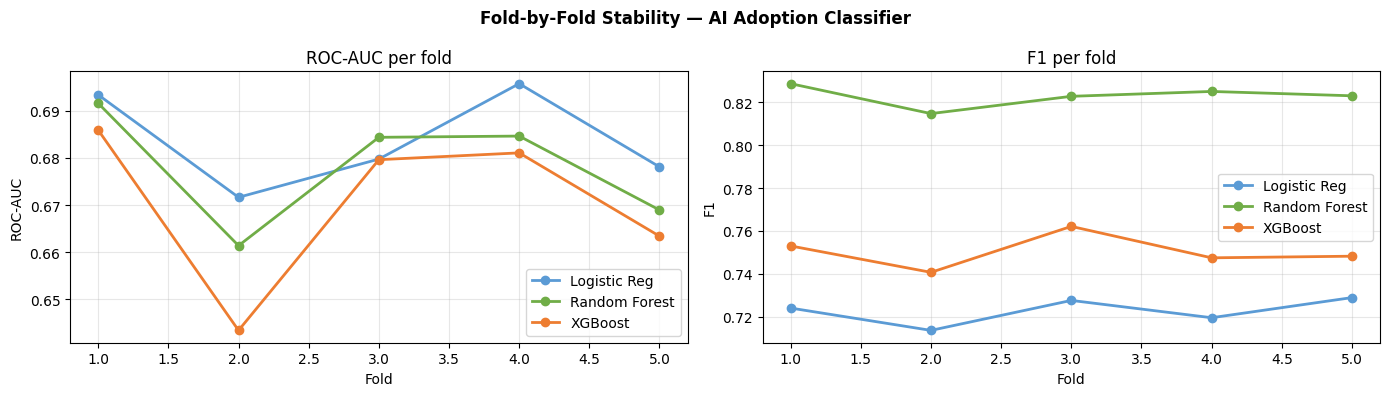

In [11]:
# ── Fold-by-fold stability plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Fold-by-Fold Stability — AI Adoption Classifier', fontsize=12, fontweight='bold')

fold_nums = list(range(1, config.N_FOLDS + 1))
colors    = ['#5B9BD5', '#70AD47', '#ED7D31']

for name, short, color in zip(model_names, short_names, colors):
    axes[0].plot(fold_nums, all_cv[name]['fold_aucs'], marker='o', label=short, color=color, linewidth=2)
    axes[1].plot(fold_nums, all_cv[name]['fold_f1s'],  marker='o', label=short, color=color, linewidth=2)

axes[0].set_title('ROC-AUC per fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('F1 per fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'fold_stability.png'), dpi=150, bbox_inches='tight')
plt.show()

## MODEL SELECTION

**Decision criteria:**
1. CV ROC-AUC (primary — handles imbalance correctly)
2. If AUC difference < 0.005 → prefer lower AUC std (consistency)
3. If still tied → prefer CV F1

In [12]:
def select_best_classifier(results_dict, pipelines_dict, tolerance=0.005):
    """
    Intelligent classifier selection.
    Primary  : highest CV ROC-AUC
    Secondary: lowest AUC std (consistency), if primary metric within tolerance
    Tertiary : highest CV F1
    """
    candidates = pd.DataFrame([
        {
            'name'    : name,
            'cv_auc'  : res['cv_auc'],
            'auc_std' : res['cv_auc_std'],
            'cv_f1'   : res['cv_f1'],
            'f1_std'  : res['cv_f1_std'],
        }
        for name, res in results_dict.items()
    ]).sort_values('cv_auc', ascending=False)

    best_auc = candidates.iloc[0]['cv_auc']

    # Candidates within tolerance of best AUC
    within_tol = candidates[candidates['cv_auc'] >= best_auc - tolerance]

    if len(within_tol) > 1:
        winner_row = within_tol.sort_values(['auc_std', 'cv_f1'], ascending=[True, False]).iloc[0]
        reason = f'AUC within tolerance ({tolerance}); selected for lower std ({winner_row["auc_std"]:.4f})'
    else:
        winner_row = candidates.iloc[0]
        reason = f'Highest CV ROC-AUC ({winner_row["cv_auc"]:.4f})'

    winner_name     = winner_row['name']
    winner_pipeline = pipelines_dict[winner_name]

    print('\nMODEL SELECTION RESULT')
    print('=' * 50)
    print(f'  Winner  : {winner_name}')
    print(f'  Reason  : {reason}')
    print(f'  CV AUC  : {winner_row["cv_auc"]:.4f}  ±{winner_row["auc_std"]:.4f}')
    print(f'  CV F1   : {winner_row["cv_f1"]:.4f}  ±{winner_row["f1_std"]:.4f}')
    print('=' * 50)

    return winner_name, winner_pipeline


winner_name, winner_pipeline = select_best_classifier(all_cv, PIPELINES)


MODEL SELECTION RESULT
  Winner  : Logistic Regression
  Reason  : Highest CV ROC-AUC (0.6837)
  CV AUC  : 0.6837  ±0.0093
  CV F1   : 0.7227  ±0.0056


## FINAL TRAINING — WINNER ON FULL TRAINING SET

In [13]:
print(f'Retraining {winner_name} on full training set ({len(X_train):,} rows)...')
winner_pipeline.fit(X_train, y_train)
print('Training complete.')

model_path = os.path.join(config.MODELS_DIR, 'best_classifier_model.pkl')
joblib.dump(winner_pipeline, model_path)
print(f'Model saved to: {model_path}')

Retraining Logistic Regression on full training set (14,411 rows)...
Training complete.
Model saved to: ./models/classification/best_classifier_model.pkl


## FINAL EVALUATION — LOCKED TEST SET

Run once. 

Accuracy (0.6325) falls below the naive baseline of 0.8163 (always predict 'Uses AI'). This is an expected consequence of class_weight='balanced' — the model trades majority-class accuracy for minority-class recall. The relevant metrics are ROC-AUC (0.6984) and the per-class precision/recall breakdown below.

In [14]:
print('FINAL TEST SET EVALUATION')
print('=' * 55)

y_pred_proba = winner_pipeline.predict_proba(X_test)[:, 1]
y_pred       = winner_pipeline.predict(X_test)

test_auc = roc_auc_score(y_test, y_pred_proba)
test_f1  = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f'  Model         : {winner_name}')
print(f'  Test ROC-AUC  : {test_auc:.4f}')
print(f'  Test F1       : {test_f1:.4f}')
print(f'  Test Accuracy : {test_acc:.4f}  (context only)')
print(f'\n  Naive baseline (predict all AI users): {test_pos_rate:.4f} accuracy')
print(f'  Model beats naive baseline by: {test_acc - test_pos_rate:+.4f} accuracy points')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No AI (0)', 'Uses AI (1)']))

final_results = {
    'model'    : winner_name,
    'test_auc' : float(test_auc),
    'test_f1'  : float(test_f1),
    'test_acc' : float(test_acc),
    'cv_auc'   : float(all_cv[winner_name]['cv_auc']),
    'cv_f1'    : float(all_cv[winner_name]['cv_f1']),
}
with open(os.path.join(config.RESULTS_DIR, 'final_test_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
print('Final results saved.')

FINAL TEST SET EVALUATION
  Model         : Logistic Regression
  Test ROC-AUC  : 0.6984
  Test F1       : 0.7350
  Test Accuracy : 0.6325  (context only)

  Naive baseline (predict all AI users): 0.8163 accuracy
  Model beats naive baseline by: -0.1837 accuracy points

Classification Report:
              precision    recall  f1-score   support

   No AI (0)       0.29      0.67      0.40       662
 Uses AI (1)       0.89      0.62      0.73      2941

    accuracy                           0.63      3603
   macro avg       0.59      0.65      0.57      3603
weighted avg       0.78      0.63      0.67      3603

Final results saved.


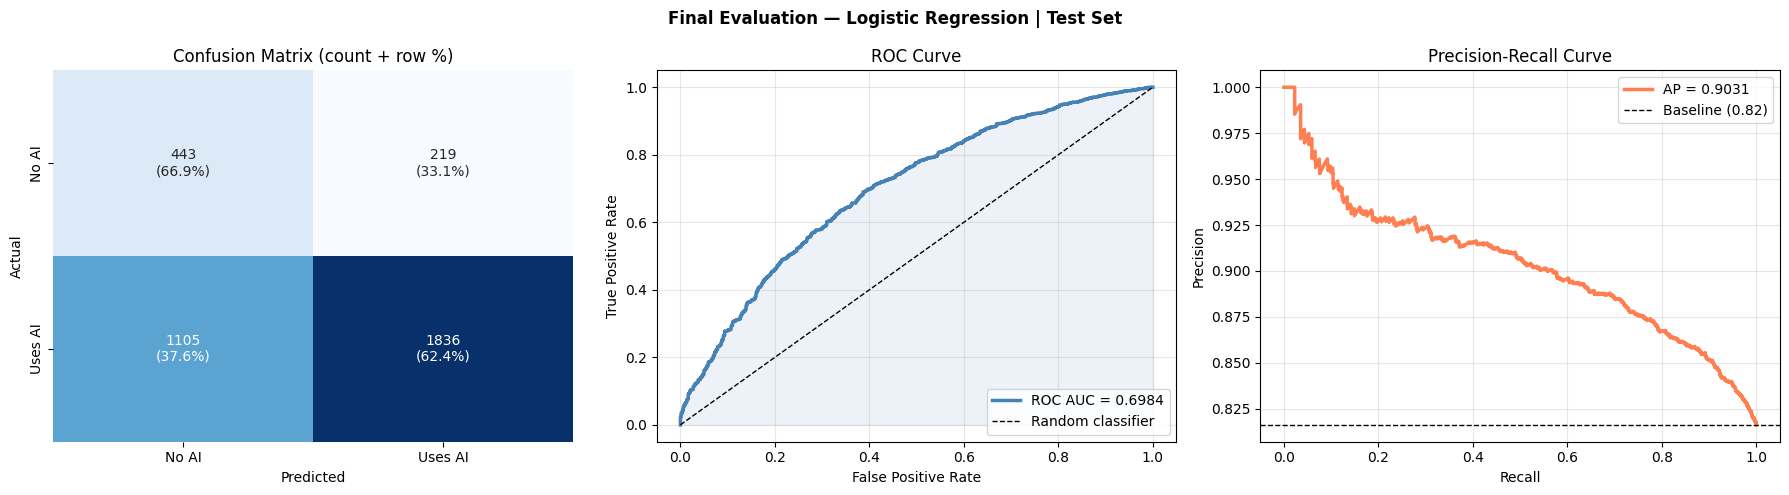

Evaluation plots saved.


In [15]:
# ── Confusion Matrix ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Final Evaluation — {winner_name} | Test Set', fontsize=12, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annot = np.array([[f'{v}\n({p:.1%})' for v, p in zip(row_v, row_p)]
                  for row_v, row_p in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['No AI', 'Uses AI'],
            yticklabels=['No AI', 'Uses AI'],
            ax=axes[0], cbar=False)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (count + row %)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'ROC AUC = {test_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)
axes[2].plot(recall, precision, color='coral', linewidth=2.5, label=f'AP = {avg_prec:.4f}')
axes[2].axhline(train_pos_rate, color='k', linestyle='--', linewidth=1,
                label=f'Baseline ({train_pos_rate:.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'final_test_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved.')

## SHAP ANALYSIS — WorkExp Rank & Confound Answer

This is the answer to the core question: **are senior devs just more likely to use AI?**

SHAP decomposes each prediction into per-feature contributions. The question being answered: does WorkExp drive AI adoption, and in which direction? A negative SHAP value for high WorkExp means experience suppresses adoption — confirming the EDA directional finding by a model-based method

WorkExp ranks 6th out of 102 features by mean absolute SHAP value, accounting for 4.32% of total model attribution. The direction is negative: higher experience consistently suppresses AI adoption predictions. The logistic regression coefficient (−0.1518, OR 0.859) confirms this: each additional year of experience reduces AI adoption odds by approximately 14%. The confound mechanism — senior developers inflating the AI salary premium — is not supported by either model.

In [16]:
print('Computing SHAP values for classifier...')

fitted_model        = winner_pipeline.named_steps['model']
fitted_preprocessor = winner_pipeline.named_steps['preprocessor']
X_test_transformed  = fitted_preprocessor.transform(X_test)
X_train_transformed = fitted_preprocessor.transform(X_train)

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
    feature_names = [n.split('__')[-1] for n in feature_names]
except Exception:
    feature_names = X_train.columns.tolist()

if 'XGBoost' in winner_name or 'Random Forest' in winner_name:
    explainer   = shap.TreeExplainer(fitted_model)
    sample_size = min(2000, len(X_test_transformed))
    idx_sample  = np.random.choice(len(X_test_transformed), sample_size, replace=False)
    shap_values = explainer.shap_values(X_test_transformed[idx_sample])
    X_shap      = X_test_transformed[idx_sample]
    # For Random Forest with binary classification, shap_values is a list [class0, class1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # use class 1 (UsesAI=1) SHAP values
else:
    background  = shap.sample(X_train_transformed, 500)
    explainer   = shap.LinearExplainer(fitted_model, background)
    sample_size = min(2000, len(X_test_transformed))
    idx_sample  = np.random.choice(len(X_test_transformed), sample_size, replace=False)
    shap_values = explainer.shap_values(X_test_transformed[idx_sample])
    X_shap      = X_test_transformed[idx_sample]

print(f'SHAP values computed on {sample_size} test samples.')

Computing SHAP values for classifier...
SHAP values computed on 2000 test samples.


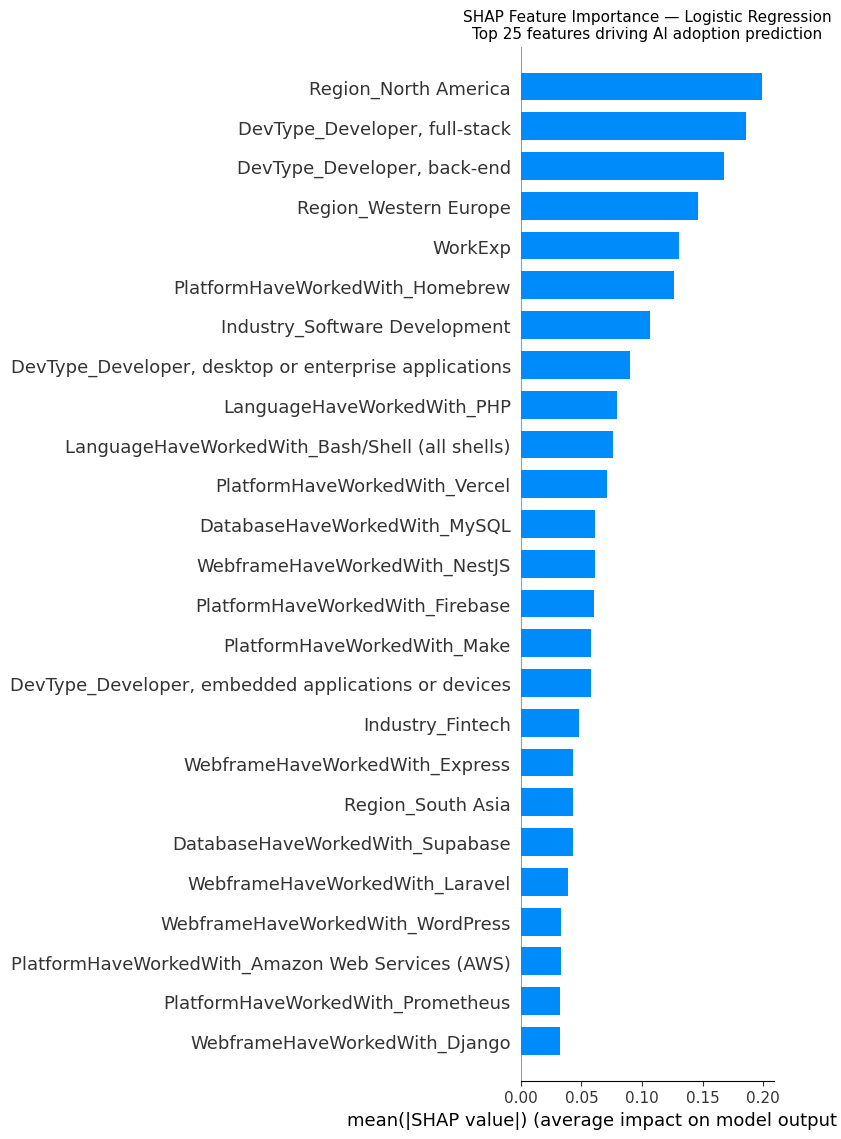

In [17]:
# ── SHAP Summary Bar Plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    plot_type='bar',
    max_display=25,
    show=False
)
plt.title(f'SHAP Feature Importance — {winner_name}\nTop 25 features driving AI adoption prediction', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'shap_bar_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

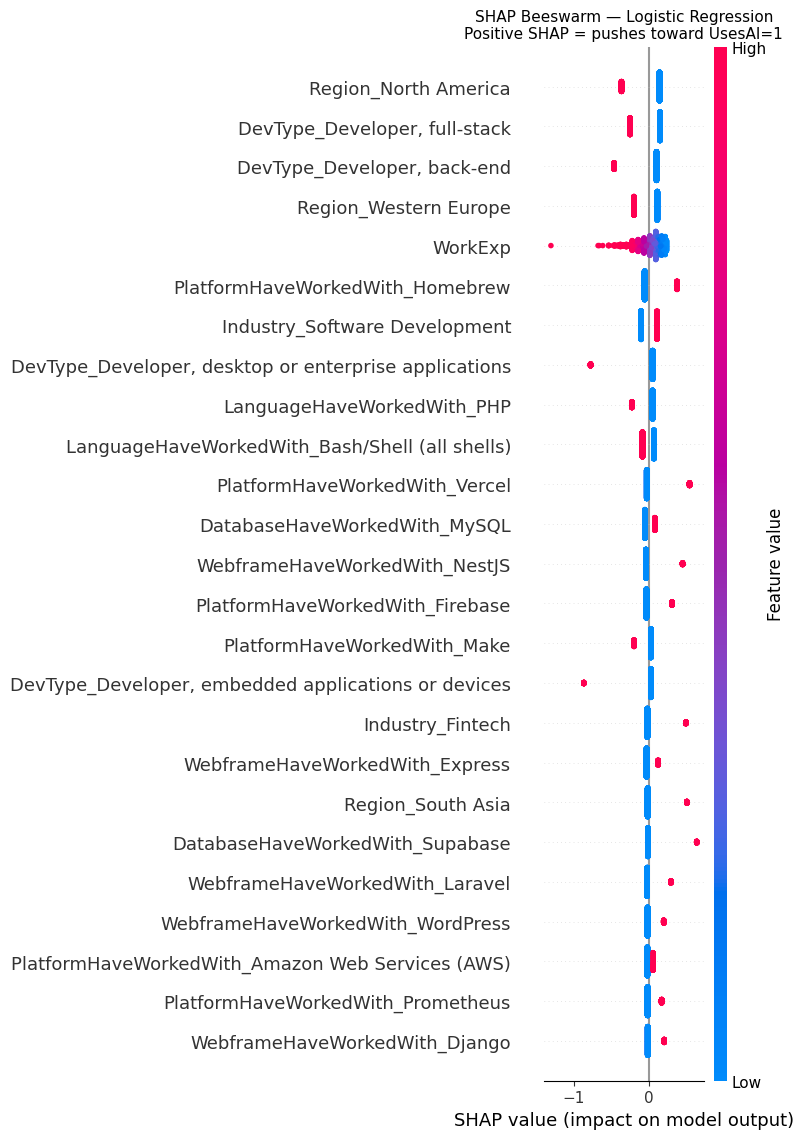

In [18]:
# ── SHAP Beeswarm ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    max_display=25,
    show=False
)
plt.title(f'SHAP Beeswarm — {winner_name}\nPositive SHAP = pushes toward UsesAI=1', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── WorkExp specific SHAP analysis — answering the confound question ───────
workexp_idx = None
for i, name in enumerate(feature_names):
    if 'WorkExp' in name:
        workexp_idx = i
        break

if workexp_idx is not None:
    workexp_shap   = shap_values[:, workexp_idx]
    workexp_vals   = X_shap[:, workexp_idx]
    mean_abs_workexp = np.abs(workexp_shap).mean()

    mean_abs_all = np.abs(shap_values).mean(axis=0)
    rank         = int(np.sum(mean_abs_all > mean_abs_workexp)) + 1
    total_feats  = len(feature_names)
    pct_attr     = mean_abs_workexp / mean_abs_all.sum() * 100

    # Direction: positive SHAP at high WorkExp → more experience → more AI adoption
    # Negative SHAP at high WorkExp → more experience → LESS AI adoption (our EDA finding)
    high_exp_mask = workexp_vals > np.median(workexp_vals)
    direction_high_exp = workexp_shap[high_exp_mask].mean()
    direction_low_exp  = workexp_shap[~high_exp_mask].mean()

    print('WorkExp — SHAP CONTRIBUTION (Confound Answer)')
    print('=' * 60)
    print(f'  Mean |SHAP| for WorkExp   : {mean_abs_workexp:.5f}')
    print(f'  Feature importance rank   : {rank} / {total_feats}')
    print(f'  % of total attribution    : {pct_attr:.2f}%')
    print(f'  SHAP direction (high exp) : {direction_high_exp:+.5f}  ← sign matters')
    print(f'  SHAP direction (low exp)  : {direction_low_exp:+.5f}')
    print()

    if direction_high_exp < 0:
        direction_label = 'NEGATIVE — more experience → LESS AI adoption'
        confound_status = 'CONFOUND MECHANISM ABSENT — EDA finding confirmed by model'
        confound_detail = ('The assumed confound (senior devs use AI more, inflating apparent salary premium) '
                           'is not supported. High-experience developers have negative SHAP values for WorkExp, '
                           'meaning experience suppresses rather than drives AI adoption in this model.')
    else:
        direction_label = 'POSITIVE — more experience → MORE AI adoption'
        confound_status = 'CONFOUND MECHANISM PRESENT — review EDA finding 2.3'
        confound_detail = ('The model finds that high-experience developers are more likely to use AI. '
                           'This would support the confounding hypothesis. Cross-check with EDA section 2.3.')

    print(f'  Direction label : {direction_label}')
    print(f'  Confound status : {confound_status}')
    print()
    print('  CONCLUSION:', confound_detail)

    conclusion_text = (
        f"WorkExp ranks {rank}/{total_feats} in SHAP importance for AI adoption prediction, "
        f"accounting for {pct_attr:.1f}% of total model attribution. "
        f"Direction at high experience: {direction_high_exp:+.5f}. "
        f"Status: {confound_status}. "
        f"{confound_detail}"
    )

    with open(os.path.join(config.RESULTS_DIR, 'workexp_shap_confound_answer.txt'), 'w') as f:
        f.write(conclusion_text)
    print('\nConfound answer saved to workexp_shap_confound_answer.txt')
else:
    print('WorkExp not found in feature names — check preprocessor output.')

WorkExp — SHAP CONTRIBUTION (Confound Answer)
  Mean |SHAP| for WorkExp   : 0.13045
  Feature importance rank   : 6 / 102
  % of total attribution    : 4.32%
  SHAP direction (high exp) : -0.08374  ← sign matters
  SHAP direction (low exp)  : +0.15185

  Direction label : NEGATIVE — more experience → LESS AI adoption
  Confound status : CONFOUND MECHANISM ABSENT — EDA finding confirmed by model

  CONCLUSION: The assumed confound (senior devs use AI more, inflating apparent salary premium) is not supported. High-experience developers have negative SHAP values for WorkExp, meaning experience suppresses rather than drives AI adoption in this model.

Confound answer saved to workexp_shap_confound_answer.txt


<Figure size 900x500 with 0 Axes>

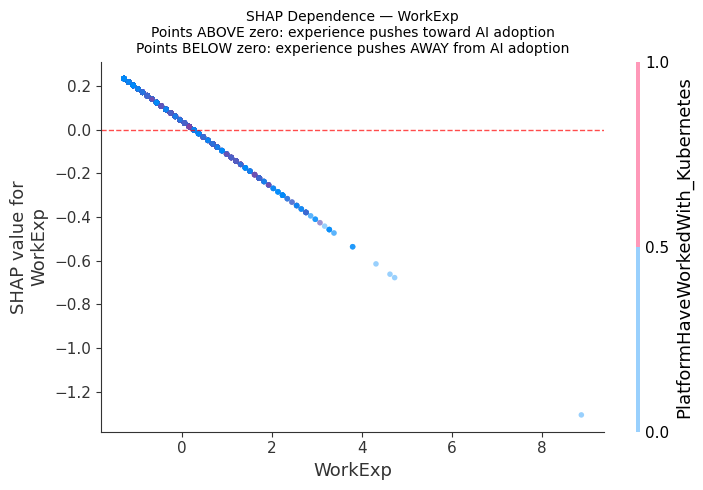

WorkExp SHAP dependence plot saved.
If the trend is downward left-to-right, the model confirms: more experience = less AI adoption.


In [20]:
# ── WorkExp SHAP dependence plot ───────────────────────────────────────────
if workexp_idx is not None:
    plt.figure(figsize=(9, 5))
    shap.dependence_plot(
        workexp_idx,
        shap_values,
        X_shap,
        feature_names=feature_names,
        show=False,
        alpha=0.4
    )
    plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.title(
        'SHAP Dependence — WorkExp\n'
        'Points ABOVE zero: experience pushes toward AI adoption\n'
        'Points BELOW zero: experience pushes AWAY from AI adoption',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'shap_workexp_dependence.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('WorkExp SHAP dependence plot saved.')
    print('If the trend is downward left-to-right, the model confirms: more experience = less AI adoption.')

## LOGISTIC REGRESSION COEFFICIENT ANALYSIS

Logistic regression coefficients are computed independently of the CV winner. Because LR is interpretable in log-odds units, its WorkExp coefficient provides a precise, linearly-estimated answer to the research question that complements the non-linear SHAP analysis. The odds ratio (exp(coefficient)) converts directly to a percentage change in adoption odds per year of experience.

In [21]:
# Fit Logistic Regression standalone for interpretability (always run, regardless of winner)
print('Fitting Logistic Regression for coefficient analysis...')
pipeline_lr.fit(X_train, y_train)

lr_model       = pipeline_lr.named_steps['model']
lr_preprocessor = pipeline_lr.named_steps['preprocessor']

try:
    lr_feature_names = [n.split('__')[-1] for n in lr_preprocessor.get_feature_names_out()]
except Exception:
    lr_feature_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    'feature'  : lr_feature_names,
    'coef'     : lr_model.coef_[0],
    'odds_ratio': np.exp(lr_model.coef_[0])
}).sort_values('coef', ascending=False)

# WorkExp coefficient — the confound check
workexp_coef = coef_df[coef_df['feature'].str.contains('WorkExp')]
print('\nWorkExp coefficient (Logistic Regression):')
print(workexp_coef[['feature', 'coef', 'odds_ratio']].to_string(index=False))

if not workexp_coef.empty:
    coef_val = workexp_coef.iloc[0]['coef']
    odds_val = workexp_coef.iloc[0]['odds_ratio']
    if coef_val < 0:
        print(f'\n  Negative coefficient ({coef_val:.4f}): each additional year of experience')
        print(f'  multiplies the odds of AI adoption by {odds_val:.4f} — i.e. reduces it.')
        print('  CONFIRMS EDA finding: senior devs are LESS likely to use AI, not more.')
    else:
        print(f'\n  Positive coefficient ({coef_val:.4f}): each additional year of experience')
        print(f'  multiplies the odds of AI adoption by {odds_val:.4f} — i.e. increases it.')

print('\nTop 10 positive predictors of AI adoption (log-odds):')
print(coef_df.head(10)[['feature', 'coef', 'odds_ratio']].to_string(index=False))

print('\nTop 10 negative predictors of AI adoption (log-odds):')
print(coef_df.tail(10)[['feature', 'coef', 'odds_ratio']].to_string(index=False))

coef_df.to_csv(os.path.join(config.RESULTS_DIR, 'logistic_regression_coefficients.csv'), index=False)

Fitting Logistic Regression for coefficient analysis...

WorkExp coefficient (Logistic Regression):
feature      coef  odds_ratio
WorkExp -0.151799    0.859161

  Negative coefficient (-0.1518): each additional year of experience
  multiplies the odds of AI adoption by 0.8592 — i.e. reduces it.
  CONFIRMS EDA finding: senior devs are LESS likely to use AI, not more.

Top 10 positive predictors of AI adoption (log-odds):
                                  feature     coef  odds_ratio
DevType_Developer, AI apps or physical AI 1.253407    3.502255
          DatabaseHaveWorkedWith_Supabase 0.651425    1.918272
    DevType_Financial analyst or engineer 0.645978    1.907852
            PlatformHaveWorkedWith_Vercel 0.571131    1.770269
                        Region_South Asia 0.522044    1.685470
                         Industry_Fintech 0.514043    1.672038
            WebframeHaveWorkedWith_NestJS 0.488509    1.629884
        Region_Middle East & North Africa 0.462150    1.587484
         

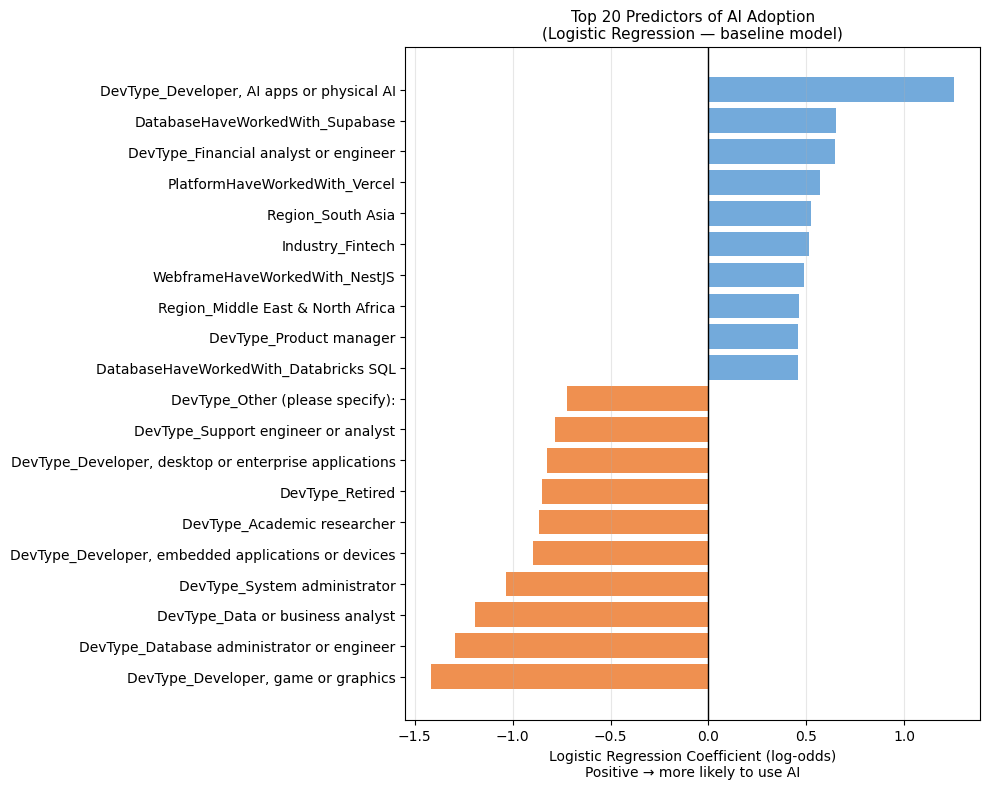

Coefficient plot saved. Red border = WorkExp — check its direction.


In [22]:
# ── Top coefficient plot ────────────────────────────────────────────────────
top_n = 20
top_pos = coef_df.head(top_n // 2)
top_neg = coef_df.tail(top_n // 2)
plot_df = pd.concat([top_pos, top_neg]).sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 8))
colors_coef = ['#ED7D31' if c < 0 else '#5B9BD5' for c in plot_df['coef']]
bars = ax.barh(plot_df['feature'], plot_df['coef'], color=colors_coef, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Logistic Regression Coefficient (log-odds)\nPositive → more likely to use AI')
ax.set_title(f'Top {top_n} Predictors of AI Adoption\n(Logistic Regression — baseline model)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Highlight WorkExp
for bar, feat in zip(bars, plot_df['feature']):
    if 'WorkExp' in feat:
        bar.set_edgecolor('red')
        bar.set_linewidth(2.5)
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                '← WorkExp', va='center', color='red', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'lr_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Coefficient plot saved. Red border = WorkExp — check its direction.')